<a href="https://colab.research.google.com/github/aabyyaann/Practical-Statistics-for-Data-Scientists/blob/main/Chapter02_Data_and_Sampling_Distributions_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 2 — Data and Sampling Distributions

## Tujuan Chapter

Pada chapter ini kita mempelajari bagaimana data dikumpulkan dari populasi dan bagaimana distribusi sampel terbentuk.

Topik yang dipelajari:

1. Population and Sample
2. Random Sampling
3. Sampling Bias
4. Sampling Distribution
5. Central Limit Theorem (CLT)
6. Standard Error
7. Bootstrap
8. Confidence Intervals
9. Normal Distribution
10. QQ Plot

Konsep-konsep ini menjadi fondasi bagi inferensi statistik dan machine learning.

# Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

np.random.seed(42)

sns.set_style("whitegrid")

# Membuat Populasi

Populasi adalah keseluruhan data yang ingin dipelajari.

In [2]:
population = np.random.normal(
    loc=50000,
    scale=10000,
    size=10000
)

population[:10]

array([54967.14153011, 48617.35698829, 56476.88538101, 65230.29856408,
       47658.46625277, 47658.63043051, 65792.12815507, 57674.34729153,
       45305.25614065, 55425.60043586])

# Statistik Populasi

In [3]:
print("Mean :", np.mean(population))
print("Std  :", np.std(population))

Mean : 49978.64016631574
Std  : 10034.122061299877


# Visualisasi Populasi

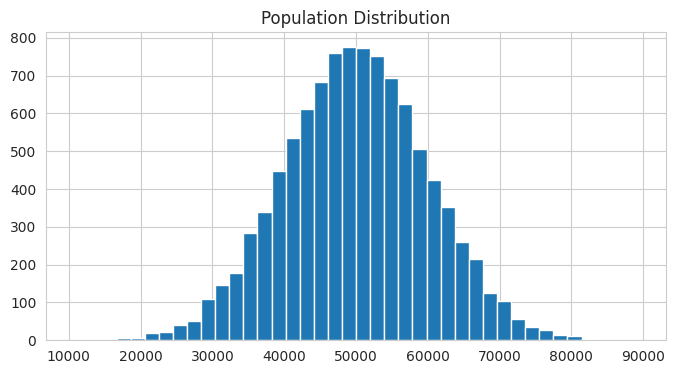

In [4]:
plt.figure(figsize=(8,4))

plt.hist(
    population,
    bins=40
)

plt.title("Population Distribution")

plt.show()

# 1. Random Sampling

Sampling adalah proses mengambil sebagian data dari populasi.

In [5]:
sample = np.random.choice(
    population,
    size=100,
    replace=False
)

sample[:10]

array([56904.72686122, 66259.58915362, 46066.48875177, 48036.50150915,
       37064.92374796, 55510.17060226, 40066.41300418, 51642.94765371,
       40448.77420651, 18295.74264122])

# Statistik Sampel

In [6]:
print("Sample Mean :", np.mean(sample))
print("Sample Std  :", np.std(sample))

Sample Mean : 51167.87915349688
Sample Std  : 10652.47953065423


# Perbandingan Populasi dan Sampel

In [7]:
print("Population Mean :", np.mean(population))
print("Sample Mean     :", np.mean(sample))

Population Mean : 49978.64016631574
Sample Mean     : 51167.87915349688


# 2. Sampling Bias

Bias terjadi ketika sampel tidak mewakili populasi.

In [8]:
biased_sample = population[
    population > 55000
]

print(np.mean(biased_sample))

61465.517836184554


# Interpretasi

Rata-rata sampel bias jauh lebih tinggi dibanding populasi.

# 3. Sampling Distribution

Kita mengambil banyak sampel dan menghitung mean masing-masing sampel.

In [9]:
sample_means = []

for _ in range(1000):

    sample = np.random.choice(
        population,
        size=50
    )

    sample_means.append(
        np.mean(sample)
    )

In [10]:
sample_means = np.array(sample_means)

sample_means[:10]

array([51556.9842867 , 51657.70716315, 49116.07676666, 48874.496606  ,
       49764.33814284, 49913.65824316, 51033.10298217, 51830.65645717,
       49352.095481  , 52658.11473053])

# Visualisasi Sampling Distribution

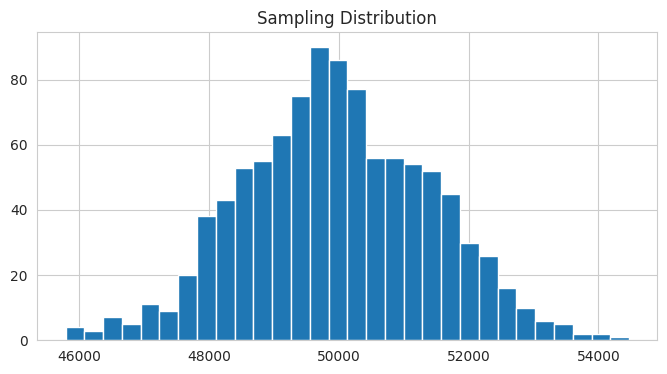

In [11]:
plt.figure(figsize=(8,4))

plt.hist(
    sample_means,
    bins=30
)

plt.title("Sampling Distribution")

plt.show()

# Perhatikan

Distribusi mean sampel cenderung mendekati distribusi normal.

# 4. Central Limit Theorem

CLT menyatakan bahwa distribusi mean sampel akan mendekati normal ketika ukuran sampel cukup besar.

In [12]:
print("Mean Sampling Distribution:")
print(np.mean(sample_means))

Mean Sampling Distribution:
49969.98660702058


In [13]:
print("Population Mean:")
print(np.mean(population))

Population Mean:
49978.64016631574


# Hasil

Nilai keduanya sangat dekat.

# 5. Standard Error

Standard Error:

\[
SE=\frac{\sigma}{\sqrt{n}}
\]

In [14]:
sigma = np.std(population)

n = 50

se = sigma / np.sqrt(n)

print(se)

1419.0391505597363


# Mengapa Standard Error Penting?

SE mengukur ketidakpastian estimasi mean sampel.

# 6. Bootstrap

Bootstrap adalah teknik resampling dengan pengembalian (replacement).

In [15]:
bootstrap_means = []

for _ in range(1000):

    bootstrap_sample = np.random.choice(
        sample,
        size=len(sample),
        replace=True
    )

    bootstrap_means.append(
        np.mean(bootstrap_sample)
    )

In [16]:
bootstrap_means = np.array(
    bootstrap_means
)

bootstrap_means[:10]

array([50427.37854764, 47883.5057321 , 51531.2319449 , 52003.40994774,
       52636.29847918, 49058.59132631, 49745.3723939 , 48865.97588913,
       51821.72336162, 49163.91357982])

# Visualisasi Bootstrap

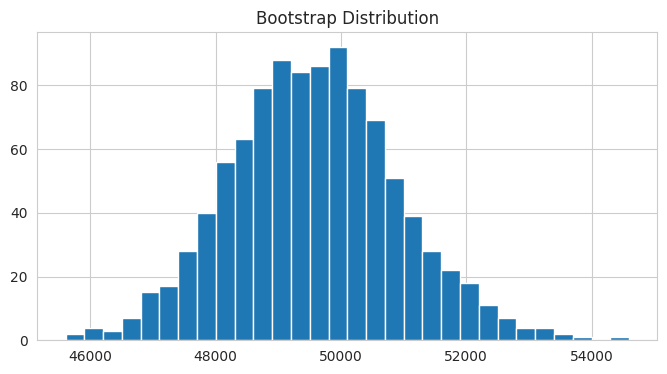

In [17]:
plt.figure(figsize=(8,4))

plt.hist(
    bootstrap_means,
    bins=30
)

plt.title("Bootstrap Distribution")

plt.show()

# 7. Confidence Interval

Confidence Interval 95%

In [18]:
lower = np.percentile(
    bootstrap_means,
    2.5
)

upper = np.percentile(
    bootstrap_means,
    97.5
)

print(lower)
print(upper)

46989.918417552784
52339.51085146488


# Interpretasi

Rentang ini menjadi estimasi lokasi mean populasi.

# 8. Normal Distribution

In [19]:
x = np.linspace(
    10000,
    90000,
    1000
)

y = stats.norm.pdf(
    x,
    np.mean(population),
    np.std(population)
)

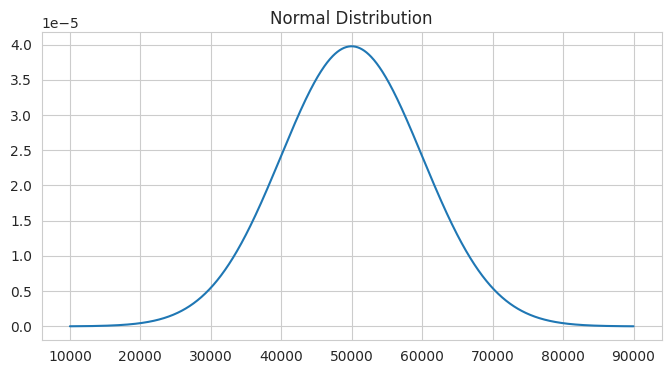

In [20]:
plt.figure(figsize=(8,4))

plt.plot(x,y)

plt.title(
    "Normal Distribution"
)

plt.show()

# Karakteristik Distribusi Normal

- Simetris
- Mean = Median = Mode
- Bentuk lonceng (bell curve)

# 9. Z-Score

Z-score menunjukkan posisi data relatif terhadap mean.

In [21]:
value = 65000

z_score = (
    value -
    np.mean(population)
) / np.std(population)

print(z_score)

1.4970278158783241


# Interpretasi

Z-score positif berarti berada di atas rata-rata.

# 10. QQ Plot

QQ Plot digunakan untuk mengecek apakah data mengikuti distribusi normal.

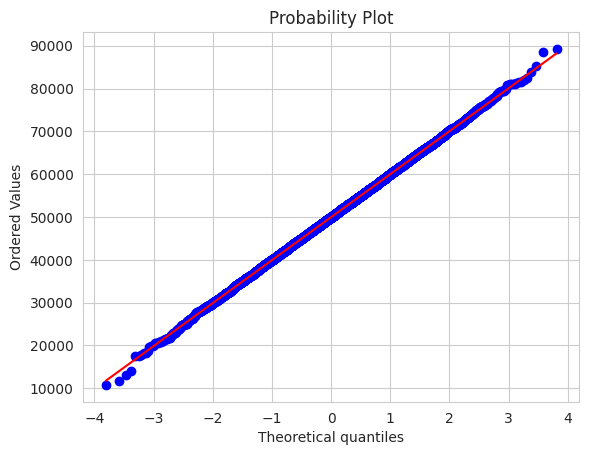

In [22]:
stats.probplot(
    population,
    dist="norm",
    plot=plt
)

plt.show()

# Interpretasi QQ Plot

Jika titik-titik mengikuti garis lurus maka distribusi data mendekati normal.

# Interpretasi QQ Plot

Jika titik-titik mengikuti garis lurus maka distribusi data mendekati normal.